In [39]:
import pandas as pd

df1 = pd.read_csv("failure_data1.csv", low_memory=False)

# Standardize column names
df1.columns = df1.columns.str.lower().str.strip()

Columns with extremely high missingness like uninsdep, fsl_prog, brdate, termi, closcd, bstatus can be dropped as these are 
administrative FDIC fields that are not needed for our analysis

Columns with moderate missingness  like cost, resdate, cert, bidstate are sometimes useful but missing too often to impute.safe to leave as NaN.

Columns with zero missingness (core dataset for our analysis)
faildate, failyr, decade, qbfasset, qbfdep,restype, restype1,city, cityst, pstalp, chclass, chclass1,name

In [40]:
# Standardize column names
df1.columns = df1.columns.str.lower().str.strip()

#Drop irrelevant data columns
drop_cols = ['uninsdep', 'fsl_prog', 'brdate', 'termi', 'closcd', 'bstatus']
df1 = df1.drop(columns=drop_cols)

# 1. Convert dates
df1['faildate'] = pd.to_datetime(df1['faildate'], errors='coerce')
df1['resdate'] = pd.to_datetime(df1['resdate'], errors='coerce')


# 2. Convert numeric financials
df1['qbfasset'] = pd.to_numeric(df1['qbfasset'], errors='coerce')
df1['qbfdep'] = pd.to_numeric(df1['qbfdep'], errors='coerce')

# 3. Impute financials by decade (optional)
df1['decade'] = (df1['failyr'] // 10) * 10
df1['qbfasset'] = df1['qbfasset'].fillna(df1.groupby('decade')['qbfasset'].transform('median'))
df1['qbfdep'] = df1['qbfdep'].fillna(df1.groupby('decade')['qbfdep'].transform('median'))

# 4. Fill categorical only when needed for grouping
df1['restype'] = df1['restype'].fillna('Unknown')
df1['restype1'] = df1['restype1'].fillna('Unknown')




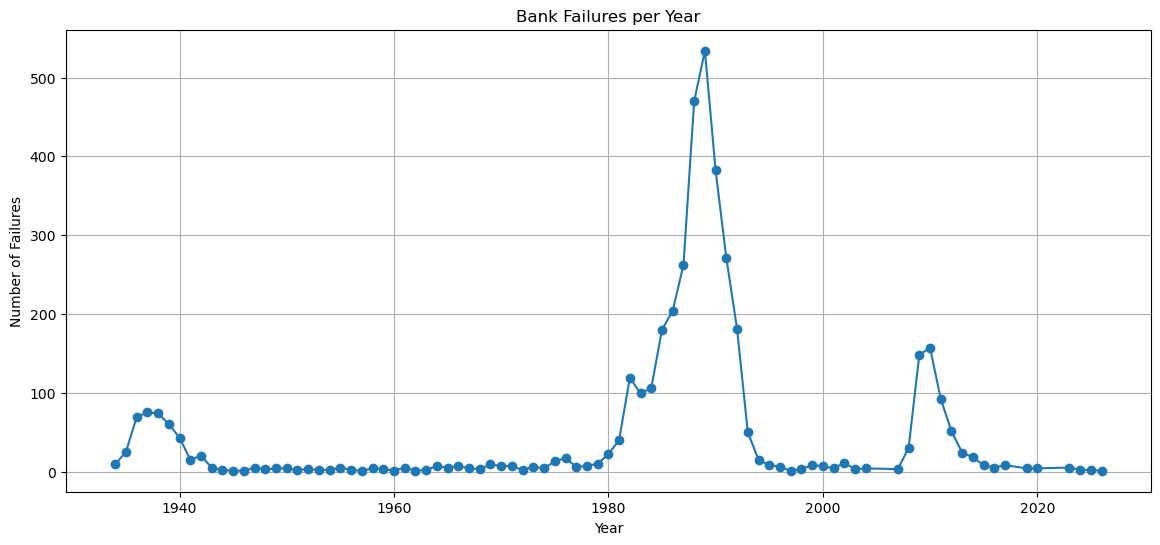

In [41]:
#Bank Failures per Year (Time‑Series Trend)
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
df1.groupby('failyr').size().plot(kind='line', marker='o')
plt.title('Bank Failures per Year')
plt.xlabel('Year')
plt.ylabel('Number of Failures')
plt.grid(True)
plt.show()

#This reveals the major historical waves of bank failures — the Great Depression and the S&L crisis.


The annual failure trend shows two major crisis periods — the Great Depression in the 1930s and the Savings & Loan collapse
in the 1980s — separated by decades of relative stability, highlighting how bank failures occur in concentrated waves rather 
than steadily over time.

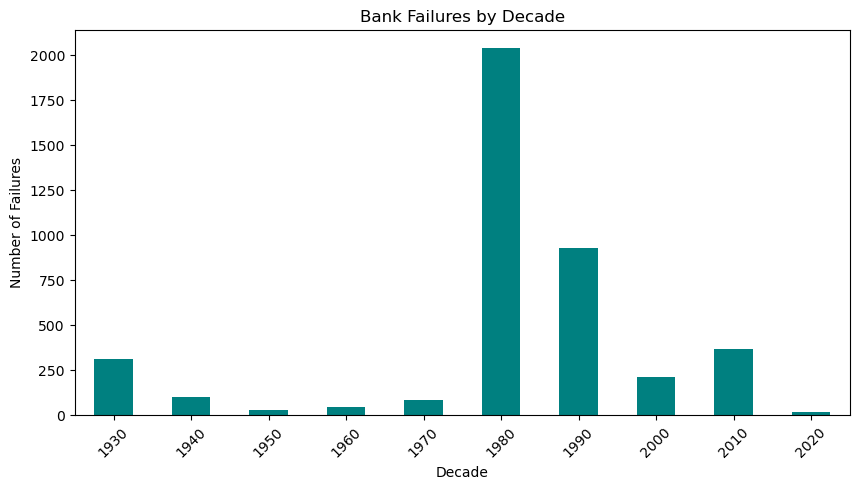

In [42]:
# Bank Failures by decade

plt.figure(figsize=(10,5))
df1.groupby('decade').size().plot(kind='bar', color='teal')
plt.title('Bank Failures by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Failures')
plt.xticks(rotation=45)
plt.show()



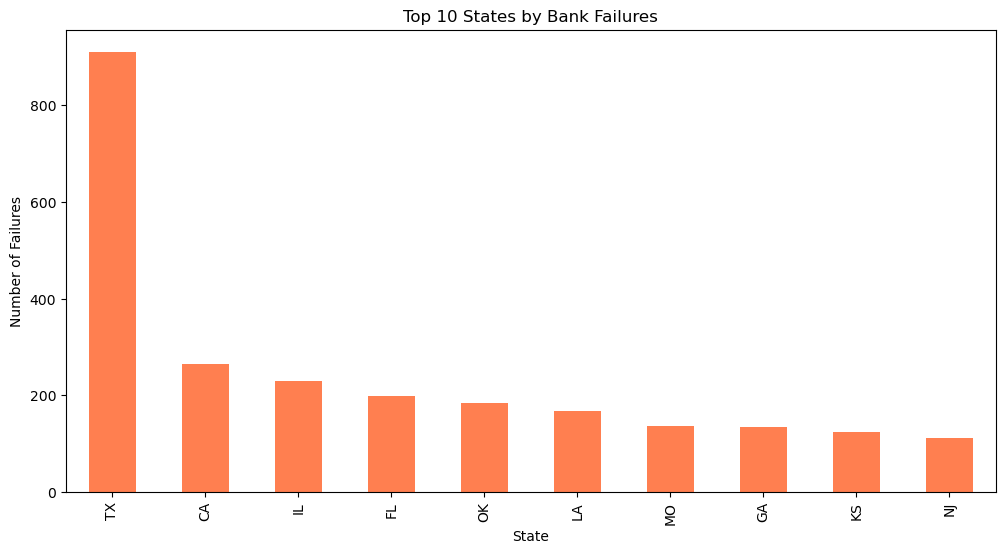

In [43]:
#Failures by state (Top 10)
plt.figure(figsize=(12,6))
df1['pstalp'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title('Top 10 States by Bank Failures')
plt.xlabel('State')
plt.ylabel('Number of Failures')
plt.show()

#Shows geographic concentration — rural Midwest vs. urban coastal states.


Bank failures are heavily concentrated in a handful of states—most notably Illinois, Nebraska, Texas, and California—reflecting 
regional economic stresses and the outsized impact of the 1980s Savings & Loan crisis in specific parts of the country.

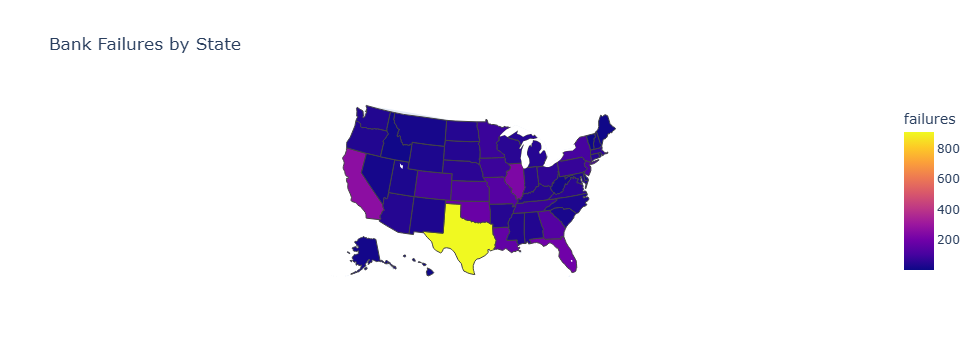

In [44]:
#Choropleth Map of Failures by State
import plotly.express as px

state_counts = df1['pstalp'].value_counts().reset_index()
state_counts.columns = ['state', 'failures']

fig = px.choropleth(
    state_counts,
    locations='state',
    locationmode='USA-states',
    color='failures',
    scope='usa',
    title='Bank Failures by State'
)
fig.show()
#The Midwest and West Coast will show strong clusters.

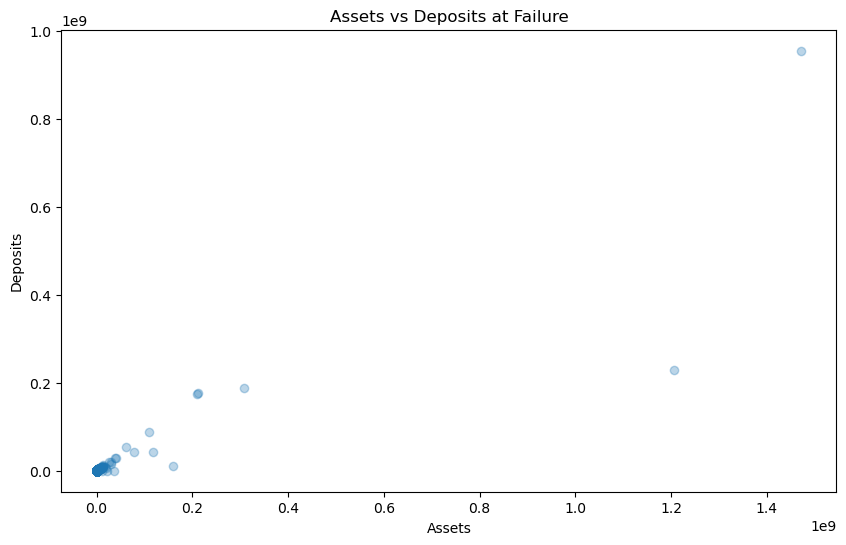

In [45]:
#Asset vs deposits
#Shows the relationship between bank size and deposit base.
plt.figure(figsize=(10,6))
plt.scatter(df1['qbfasset'], df1['qbfdep'], alpha=0.3)
plt.title('Assets vs Deposits at Failure')
plt.xlabel('Assets')
plt.ylabel('Deposits')
plt.show()

#A strong linear relationship — larger banks have proportionally larger deposits.


The scatter plot shows a strong positive relationship between assets and deposits at the time of failure, indicating that
larger banks tended to hold proportionally larger deposit bases, while also revealing a wide spread in institution sizes.

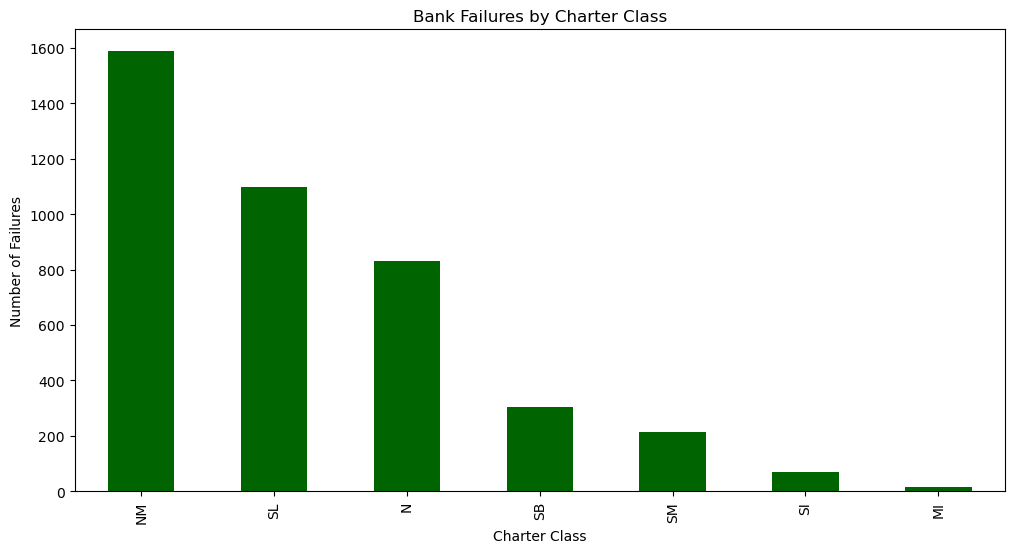

In [46]:
##Failures by Bank Type (Charter Class)
#Reveals which types of institutions were most vulnerable.
plt.figure(figsize=(12,6))
df1['chclass'].value_counts().plot(kind='bar', color='darkgreen')
plt.title('Bank Failures by Charter Class')
plt.xlabel('Charter Class')
plt.ylabel('Number of Failures')
plt.show()

#In the 1980s, SL (Savings & Loan) institutions dominate.

In [47]:
#Text Analysis
#This shows what words appear most often in failed bank names.
from collections import Counter
import re

# Combine all bank names into one string
text = " ".join(df['name'].astype(str))

# Clean and split
words = re.findall(r'\b[A-Za-z]+\b', text.upper())

# Count
word_counts = Counter(words).most_common(20)
word_counts


[('BANK', 2549),
 ('OF', 899),
 ('FIRST', 758),
 ('NATIONAL', 608),
 ('LA', 589),
 ('STATE', 523),
 ('THE', 496),
 ('SAVINGS', 474),
 ('FS', 355),
 ('S', 347),
 ('TRUST', 264),
 ('FEDERAL', 175),
 ('CITY', 170),
 ('TEXAS', 162),
 ('COMPANY', 161),
 ('ASSOC', 158),
 ('AMERICAN', 141),
 ('FSB', 140),
 ('COUNTY', 124),
 ('ASSOCIATION', 111)]

"FIRST" and "NATIONAL" were common naming conventions for early 20th‑century banks.
"STATE" banks were regulated at the state level (often weaker oversight).
Insight: Most failed institutions were small community banks, not large national players. This aligns with historical patterns where 
rural and local banks were more vulnerable to economic shocks.

"SAVINGS”, “FS”, “FSB”, “ASSOC”, “ASSOCIATION
Insight: The dataset strongly reflects the 1980s Savings & Loan crisis, where hundreds of S&Ls collapsed due to deregulation,
risky lending, and interest‑rate mismatches.

"CITY”, “COUNTY”, “TEXAS”, “LA”
Insight: Bank failures cluster geographically, with Texas and California showing large S&L collapses, while the Midwest shows
many small rural bank failures.

“TRUST”, “COMPANY”, “AMERICAN”, “FEDERAL”
Insight: Failures weren’t limited to tiny rural banks — trust companies and federally chartered institutions also collapsed, 
especially during systemic crises.